<a href="https://colab.research.google.com/github/Sruthi051006/sruthi-codeboosters-2026/blob/main/Day-4/Day_4_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#dashboard for big data
!pip install pyspark --quiet

print('pyspark installation completed')

pyspark installation completed


In [2]:
#cell - 2 -- import pyspark modules and create sparksession
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import  year, month , to_date , col , round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


# Create sparkSession
spark = SparkSession.builder \
    .appName('Day4_BigData_sales') \
    .config('spark.sql.adaptive.enable', 'true') \
    .getOrCreate()
print(f'Spark version' , {spark.version})
print(f'SparkSESSION  :ACTIVE')

print(f'Application : {spark.sparkContext.appName}')


Spark version {'4.0.2'}
SparkSESSION  :ACTIVE
Application : Day4_BigData_sales


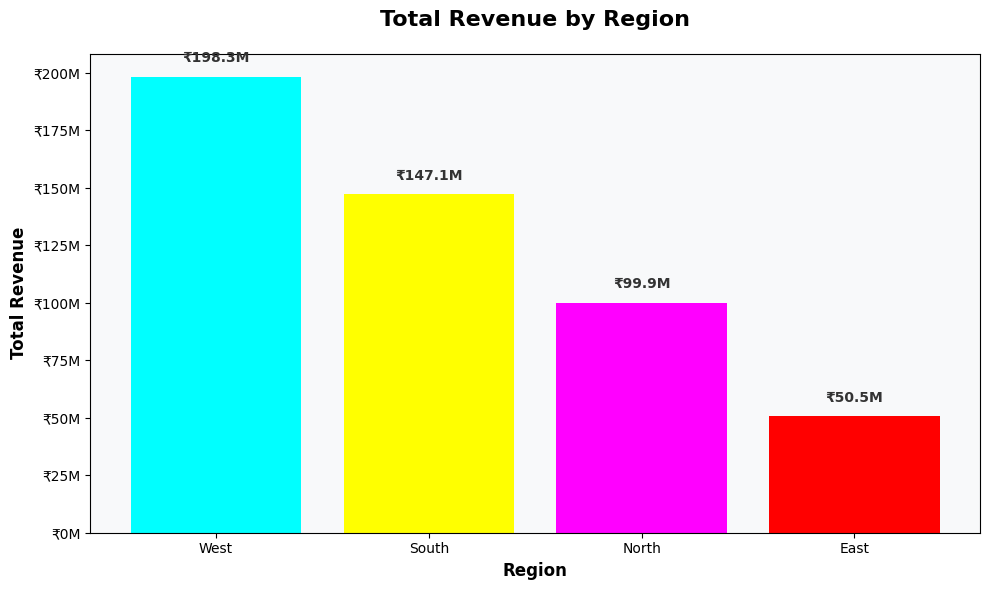

In [13]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

conn = sqlite3.connect('college.db')
df = pd.read_csv('large_sales_data.csv')
df.to_sql('students', conn, if_exists='replace', index=False)

chart1_sql = """
    SELECT region, ROUND(SUM(revenue), 2) AS total_revenue
    FROM students
    GROUP BY region
    ORDER BY total_revenue DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    chart1_data['region'],
    chart1_data['total_revenue'],
    color=['#00FFFF', '#FFFF00', '#FF00FF', '#FF0000'],
    edgecolor='white',
    linewidth=0.0
)

def millions_formatter(x, pos):
    return f'₹{x / 1_000_000:.0f}M'

ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

for bar in bars:
    height = bar.get_height()
    label_text = f'₹{height / 1_000_000:.1f}M'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5000000,
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

ax.set_title('Total Revenue by Region', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Revenue', fontsize=12, fontweight='bold')
ax.set_facecolor('#F8F9FA')
ax.grid(axis='y', linestyle='', alpha=0.5)

plt.tight_layout()
plt.show()
